# Lab 3: Complete Focal Mechanism Inversion Pipeline

In this lab, you will learn how to:

- run the complete `dasfm` pipeline from raw data to focal mechanism solutions
- Visualize focal mechanism solutions
- Summarize quality grading (A/B/C/D)

For detailed explanations of each step, see Labs 3a (ray parameters), 3b (DAS preprocessing), 3c (inversion), and 3d (result summary).


## Setup

In [24]:
# Install dasfm (only needed once)
#%pip install -e /home/jovyan/workshop-repo/notebooks/lab3_focal_mechanisms/dasfm-package

In [25]:
import torch
from dasfm.steps import (
    step1_sta_1d, step1_sta_2d, step1_sta_3d,
    step1_das_1d, step1_das_2d, step1_das_3d,
    step2a_window, step2b_polarity, step2c_spratio,
    step3_invert, step3_plot,
    step4_summarize,
)

## 1. Set Input Data File Paths and Parameters

### Input Data and Description
| File | Description |
|------|-------------|
| `EVENT_CATALOG` | Event catalog CSV (`event_id`, `latitude`, `longitude`, `depth_km`, `magnitude`) |
| `VEL_1D` | 1-D P-wave velocity model (`depth_km`, `Vp_km_s`), used for ray tracing in all methods |
| `TOPO` | Topography GeoTIFF from [OpenTopography](https://opentopography.org/), required for 2D/3D methods |
| `STA_GEO` | Station geometry CSV (`network`, `station`, `latitude`, `longitude`), defines conventional seismic stations |
| `DAS_GEO` | DAS channel geometry CSV (`index`, `latitude`, `longitude`), defines fiber-optic channel positions |
| `STA_POL` | Station P-wave first-motion polarity picks (`event_id`, `network`, `station`, `p_polarity`) |
| `STA_SP` | Station S/P amplitude ratios (`event_id`, `network`, `station`, `sp_ratio`, `takeoff`, `azimuth`) |
| `DAS_RAW_DATA` | Directory of raw DAS waveform HDF5 files (one per event), input to Step 2a |
| `DAS_RAW_TIME` | Directory of PhaseNet-DAS phase pick CSV files (one per event, `channel_index`, `phase_type`, `phase_index`) |


### Other Parameters
- `PROJECT_DIR`  Path to the project directory, including all input, intermediate, and output files
- `DEVICE`  Compute device (CPU or GPU). GPU is recommended for better performance.
- `RESULT_DIR`  Path to the directory where inversion results are stored (`PROJECT_DIR / RESULT_DIR`).
- `BEST_ONLY`  Controls how inversion quality is summarized: True = best solution per event; False = all accepted solutions.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  REQUIRED PARAMETERS — edit these before running
# ══════════════════════════════════════════════════════════════════════

# ── Project ──────────────────────────────────────────────────────────
PROJECT_DIR = "../Inputs/proj_25events"
DEVICE      = "cuda:1" if torch.cuda.is_available() else "cpu"


# ── Input file paths (relative to PROJECT_DIR) ──────────────────────
EVENT_CATALOG = "input/catalog_25events.csv"
VEL_1D        = "input/1D_velocity_MAM.txt"
TOPO          = "input/SRTMGL1_LongValley.tif"
STA_GEO       = "input/all_stations.csv"
DAS_GEO       = "input/das_info.csv"
STA_POL       = "input/polarity_LongValley.csv"
STA_SP        = "input/SP_ratio_25events.csv"
DAS_RAW_DATA  = "input/das_raw/H5"
DAS_RAW_TIME  = "input/das_raw/phase_picks"

# ── Inversion modes ─────────────────────────────────────────────────
INVERSION_TYPES = [
    "sta_pol",
    "sta_pol + sta_sp",
    "das_pol",
    "das_pol + das_sp",
    "sta_pol + das_pol",
    "sta_pol + das_sp",
    "sta_pol + das_pol + das_sp",
]

# ── Result directory ────────────────────────────────────────────────
RESULT_DIR = "result_try1"
 
# ── Summarize solutions ────────────────────────────────────────────────
BEST_ONLY = True 
# If True, use only the best solution per event; otherwise include all accepted solutions

print(f"Project: {PROJECT_DIR}  |  Device: {DEVICE}")

In [36]:
# ══════════════════════════════════════════════════════════════════════
#  DEFAULT PARAMETERS — no need to change for most use cases
# ══════════════════════════════════════════════════════════════════════
SHOW_PLOTS  = True
NUM_CPU     = 1

# Intermediate file paths
DAS_WIN         = "cache/das_win"           # time-domain windows (consumed by step2c)
DAS_FFT         = "cache/das_fft"           # FFT cache (consumed by step2b)
MCCC_CACHE_PATH = "cache/mccc_pol/mccc_direct.h5"
DAS_POL         = "cache/mccc_pol/polarity_direct.h5"
DAS_SP          = "cache/sp_ratios/sp_ratios.h5"

# Step 1: Forward modeling
FORWARD_METHOD      = "2d"        # "1d" | "2d" | "3d"
GRID_SPACE          = 0.2         # Grid spacing (km)
AZIMUTH_INTERP_DEG  = 5.0         # Azimuth interpolation step (deg, 2D only)
DAS_SUBSAMPLE       = 20          # DAS channel subsampling interval (2D/3D)
FIBER_BEND_THRESH   = 20.0         # Fiber bend threshold (deg, 2D/3D)
COMPUTE_UNCERTAINTY = False
MC_TRIALS           = None
VERT_UNC            = None
HORIZ_UNC           = None

# Step 2a: Waveform windowing
FREQ_MIN     = 1.0               # Bandpass lower corner (Hz)
FREQ_MAX     = 10.0              # Bandpass upper corner (Hz)
CUT_HALF_SEC = 1.0               # Half-window around phase pick (seconds)
HILBERT      = False              # Hilbert P/S wave separation

# Step 2b: MCCC polarity
STA4MCCC_REF        = ""
POLARITY_METHOD     = "direct"    # "direct" | "hilbert"
POLARITY_SMOOTH_WIN = 20
MCCC_MAX_LAG_SEC    = 0.5
MCCC_MAXWIN         = 10
MCCC_DAMP           = 1.0
MCCC_MAX_SHIFT      = 2
CAL_MIN_PICKS       = 5
SPARSE_SOLVE        = False

# Step 3: Inversion
VS_VP_RATIO         = 1.7
SP_DECAY_K          = None        # Linear distance decay coefficient (per km), None = no correction
SP_DECAY_C          = None        # Constant S/P offset, None = no offset
# Both None → per-event mean alignment auto-absorbs all bias (default)
WEIGHTED_POLARITY   = False
DAS_POL_WEIGHT      = 0.5
SDR_GRID_DANG       = 5.0
INIT_POL_ERROR      = 0.02
INIT_AMP_ERROR_PERC = 0.005
JOINT_POL_SIZE      = 60
SP_NORM             = "L1"        # "L1", "L2", or "cauchy"
FIG_DIR             = None       # Output fig dir (None = {RESULT_DIR}/event_figs)


## Step 1 — Compute Ray Parameters (Lab 3a)

Compute source-receiver ray parameters (traveltime, takeoff angle, azimuth, ray distance) for all stations and DAS channels. Three forward modeling methods are supported:

- **1D** — SKHASH-style lookup table from a 1D velocity model (fast, no topography)
- **2D** — Fast Sweeping Method (FSM) on radial cross-sections with topography (default)
- **3D** — Full 3D Eikonal solver via pykonal (slow, supports lateral heterogeneity)

For DAS, channels are subsampled (every 20th + bend points) to reduce computation, then interpolated back to all channels along the fiber.


  step1_sta_2d — Compute STA ray parameters (2D FSM)

[1/6] Loading input data...  (method: STA 2D)

[2/6] Building Cartesian grid (dr=dz=0.2 km, depth_max=26.5 km)...
[build_model_grid]  origin (37.57345°N, -118.82709°E)
  x (north) [0.00 … 87.20] km  nx=437  dx=0.2 km
  y (east)  [0.00 … 87.40] km  ny=438  dy=0.2 km
  z (depth) [0.00 … 30.80] km  nz=155  dz=0.2 km
  h_max=4.310 km  (z=0 ↔ 4.310 km a.s.l., sea level at z=4.310 km)
  n_events=25  n_receivers=38


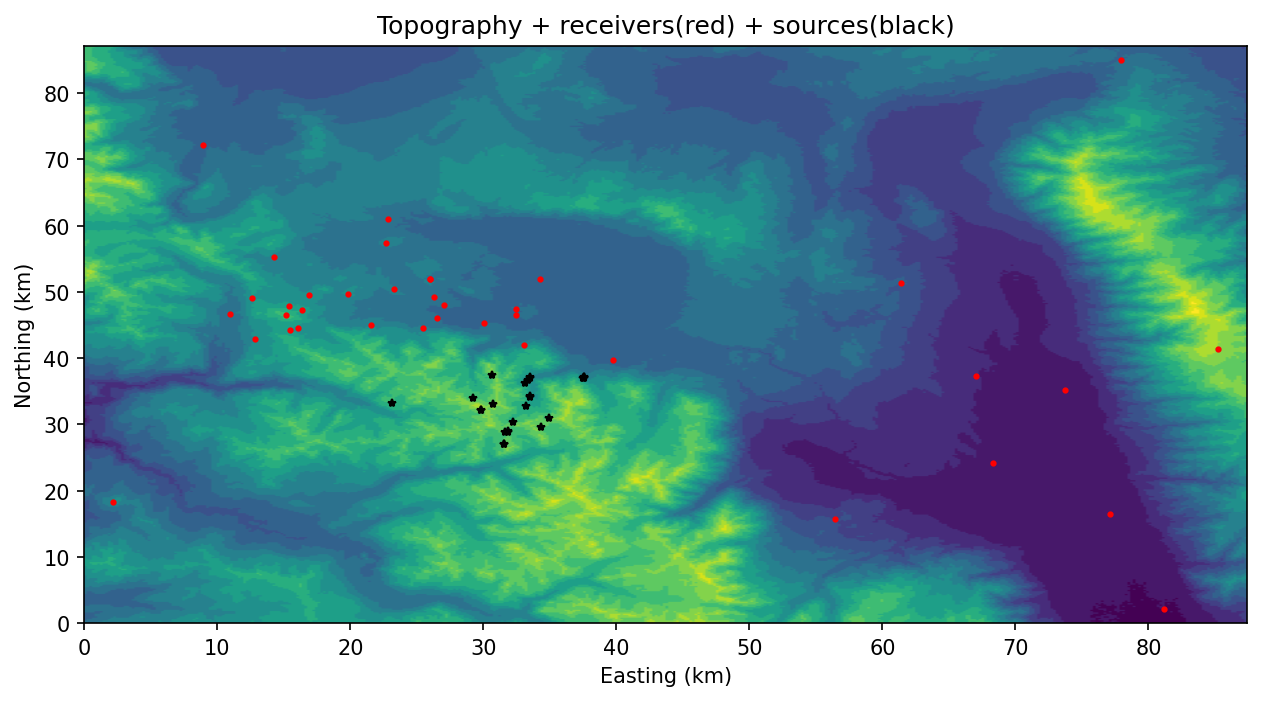

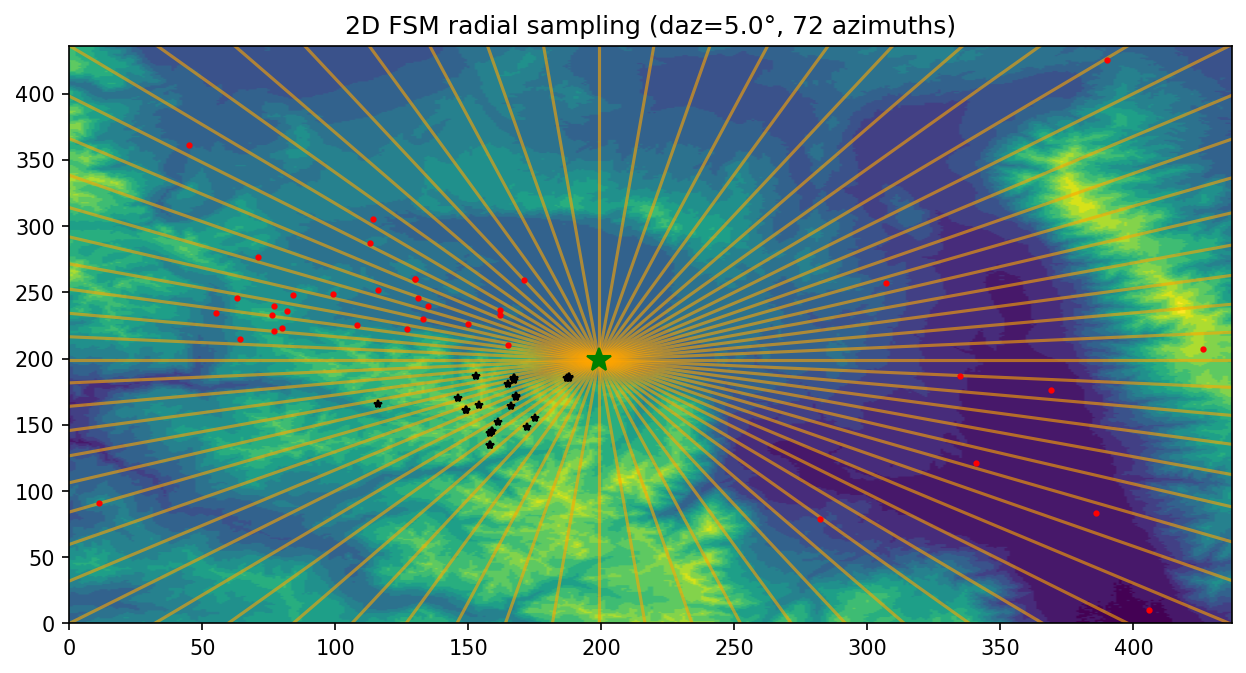


[3/6] Computing 2-D lookup tables for 38 stations...


stations: 100%|██████████| 38/38 [00:49<00:00,  1.31s/sta]



[4/6] Extracting source parameters...


Interpolating computed channels: 100%|██████████| 38/38 [00:04<00:00,  7.94it/s]



[6/6] Saving ray parameter table...
  → /home/tyan/joint_inversion/new_package/proj_25events/cache/ray_params/table_sta_2d.h5


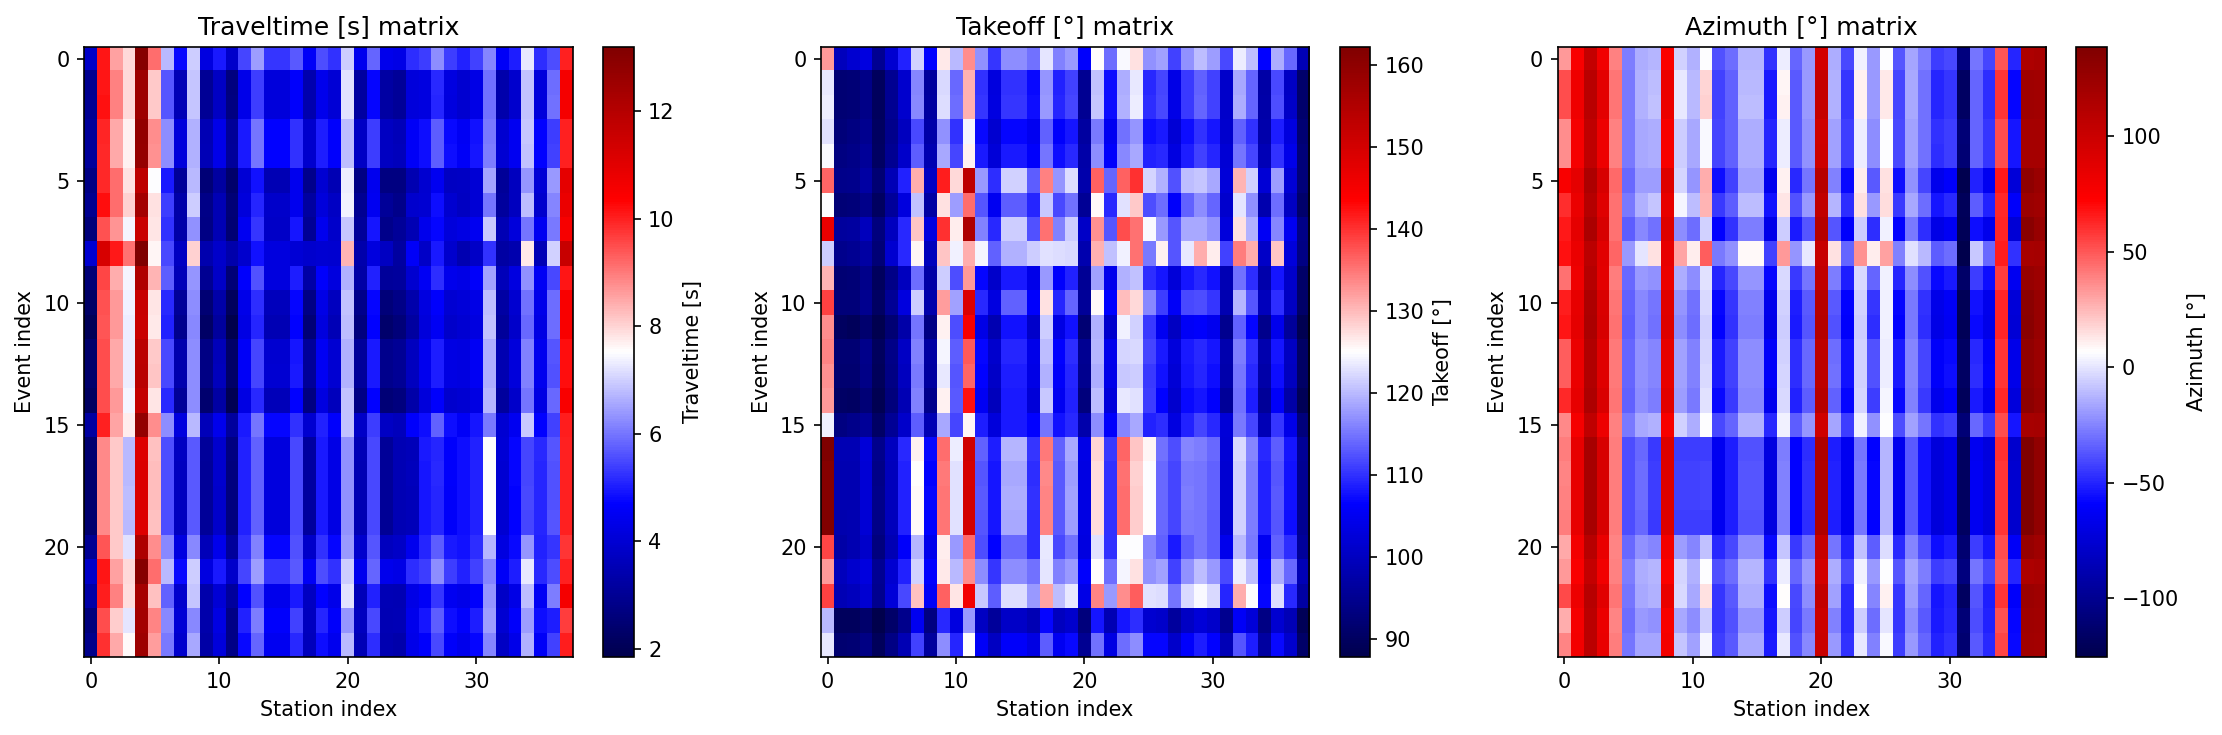

  → /home/tyan/joint_inversion/new_package/proj_25events/cache/figs/stage1_sta_2d  (3 plots)
  Done  (56.2 s)


In [28]:
# Step 1a — Stations
if FORWARD_METHOD == "1d":
    step1_sta_1d(PROJECT_DIR, EVENT_CATALOG, STA_GEO, VEL_1D,
        grid_spacing_km=GRID_SPACE, compute_uncertainty=COMPUTE_UNCERTAINTY,
        monte_carlo_trials=MC_TRIALS, vertical_uncertainty_km=VERT_UNC,
        horizontal_uncertainty_km=HORIZ_UNC, show_plots=SHOW_PLOTS,
        num_cpu_workers=NUM_CPU)
elif FORWARD_METHOD == "2d":
    step1_sta_2d(PROJECT_DIR, EVENT_CATALOG, STA_GEO, VEL_1D, TOPO,
        grid_spacing_km=GRID_SPACE, azimuth_interp_deg=AZIMUTH_INTERP_DEG,
        compute_uncertainty=COMPUTE_UNCERTAINTY, monte_carlo_trials=MC_TRIALS,
        vertical_uncertainty_km=VERT_UNC, horizontal_uncertainty_km=HORIZ_UNC,
        show_plots=SHOW_PLOTS,
        num_cpu_workers=NUM_CPU)
elif FORWARD_METHOD == "3d":
    step1_sta_3d(PROJECT_DIR, EVENT_CATALOG, STA_GEO, VEL_1D, TOPO,
        grid_spacing_km=GRID_SPACE, compute_uncertainty=COMPUTE_UNCERTAINTY,
        monte_carlo_trials=MC_TRIALS, vertical_uncertainty_km=VERT_UNC,
        horizontal_uncertainty_km=HORIZ_UNC, show_plots=SHOW_PLOTS,
        num_cpu_workers=NUM_CPU)


  step1_das_2d — Compute DAS ray parameters (2D FSM)

[1/7] Loading input data...  (method: 2D)

[2/7] Building Cartesian grid (dr=dz=0.2 km, depth_max=26.5 km)...
[build_model_grid]  origin (37.59650°N, -118.76538°E)
  x (north) [0.00 … 25.20] km  nx=127  dx=0.2 km
  y (east)  [0.00 … 34.20] km  ny=172  dy=0.2 km
  z (depth) [0.00 … 30.60] km  nz=154  dz=0.2 km
  h_max=3.968 km  (z=0 ↔ 3.968 km a.s.l., sea level at z=3.968 km)
  n_events=25  n_receivers=4670


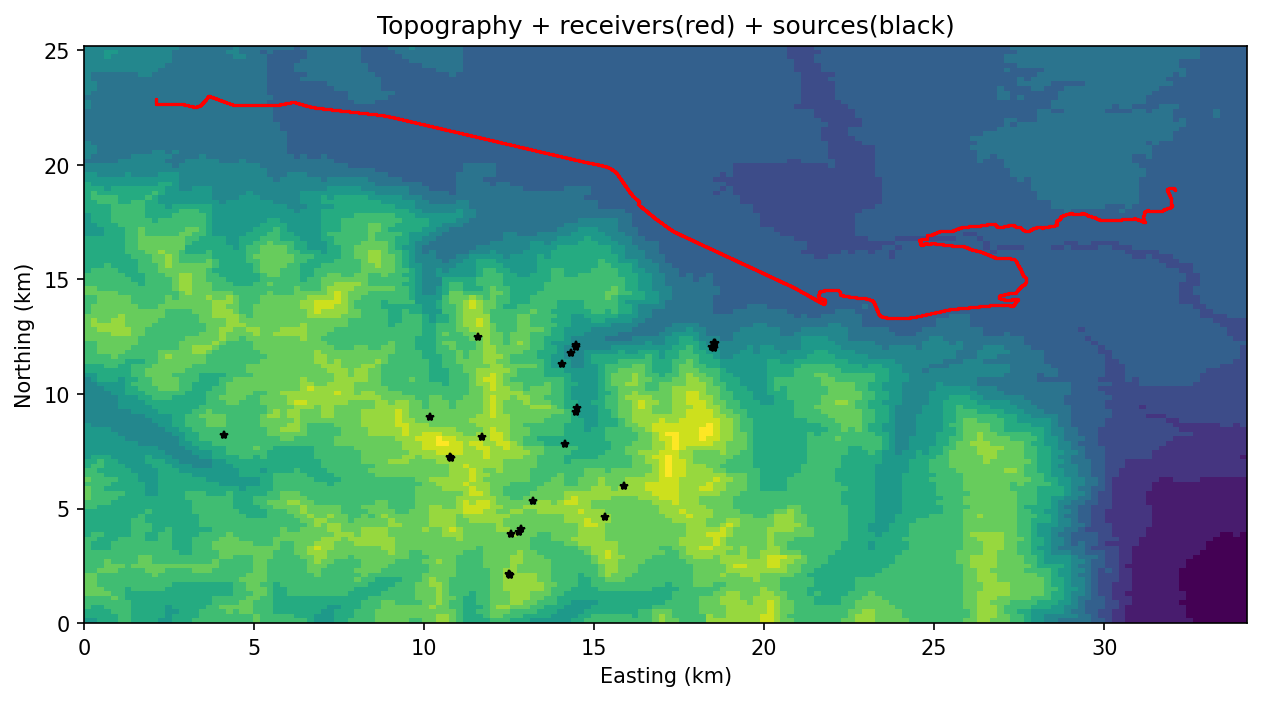


[3/7] Subsampling DAS channels...
[subsample_das_channels]  n_ch=4670  dc=20  smooth_window=20  cum_bend_threshold=20.0°
  uniform: 235  cum-bends: 179  union: 404  (compression 11.6×)


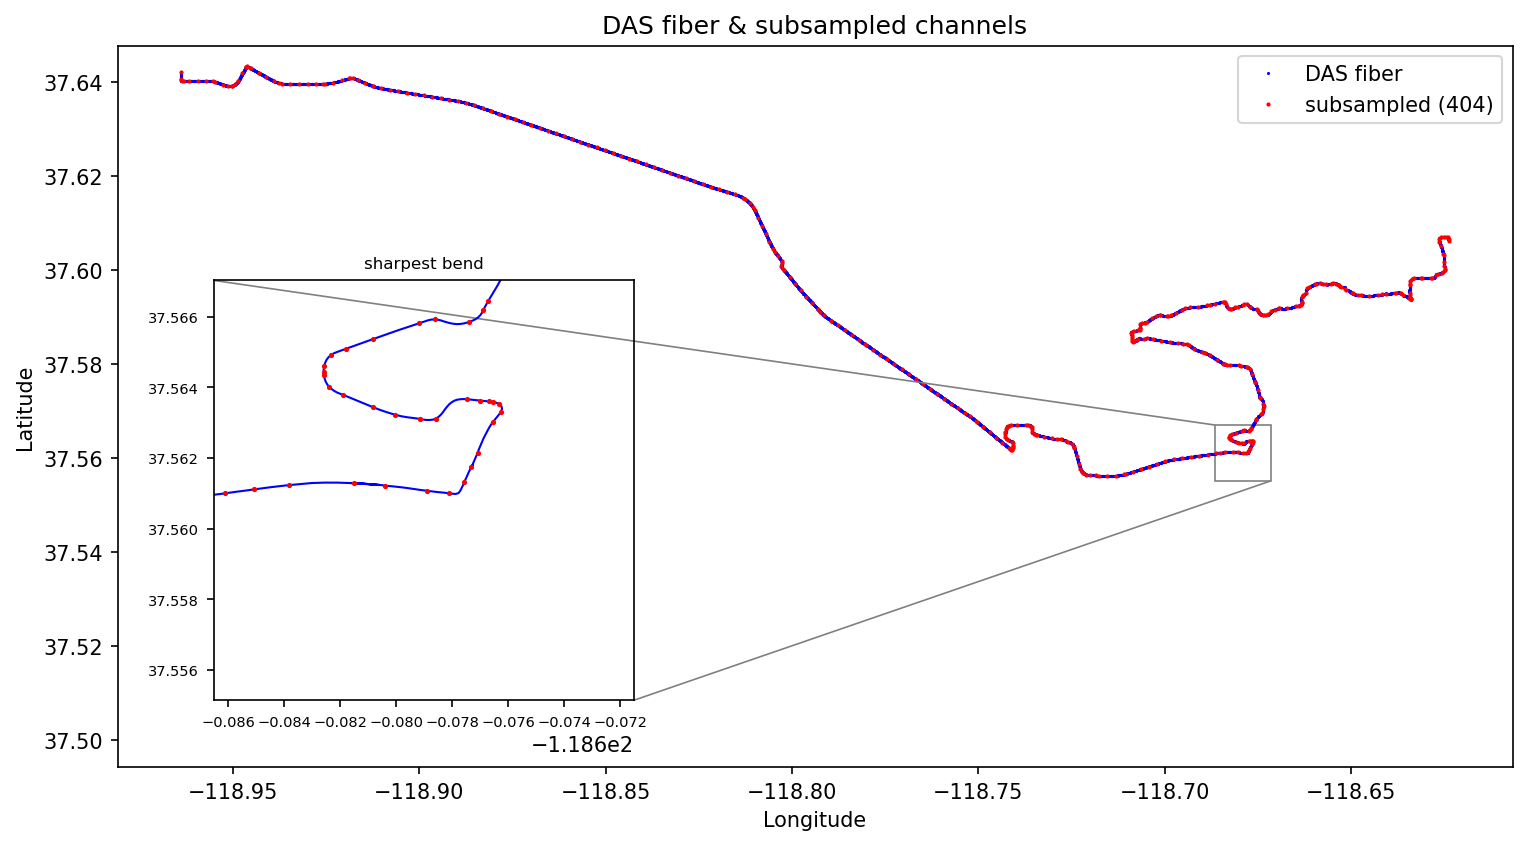

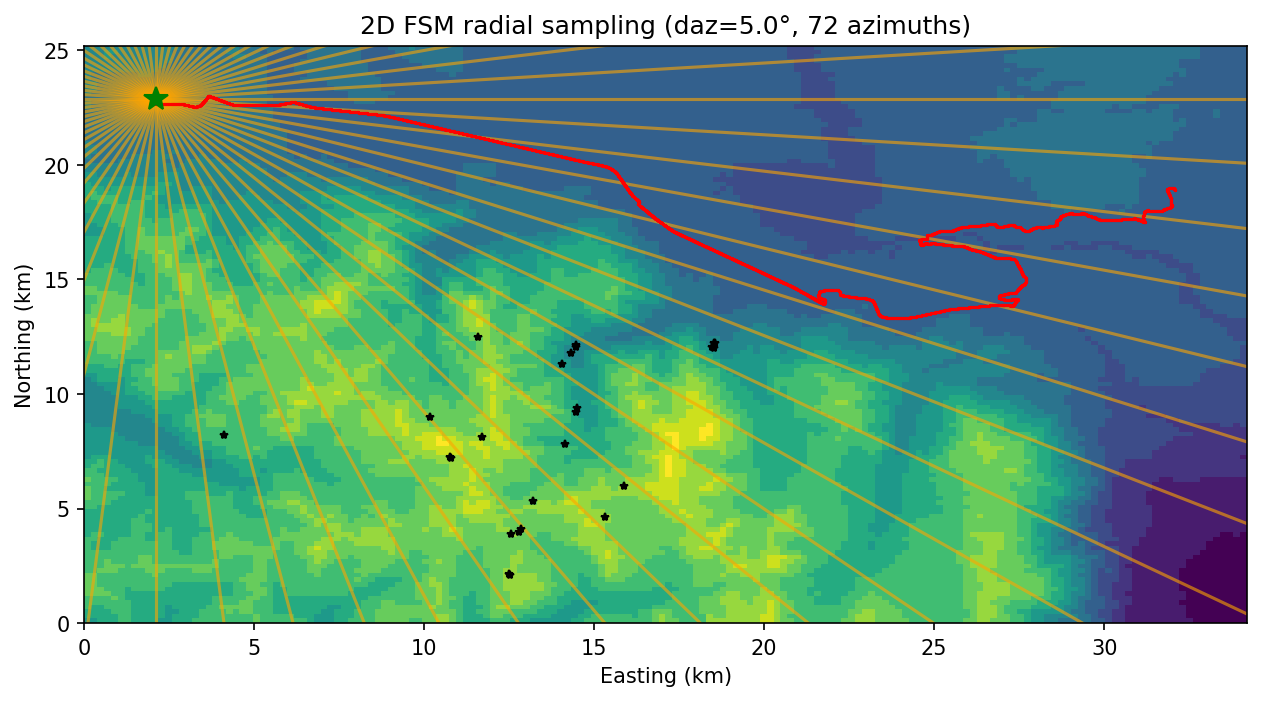


[4/7] Computing 2-D lookup tables for 404 channels...


channels: 100%|██████████| 404/404 [03:05<00:00,  2.17ch/s]



[5/7] Interpolating source parameters...


Interpolating computed channels: 100%|██████████| 404/404 [00:22<00:00, 18.10it/s]



[7/7] Saving ray parameter table...
  → /home/tyan/joint_inversion/new_package/proj_25events/cache/ray_params/table_das_2d.h5


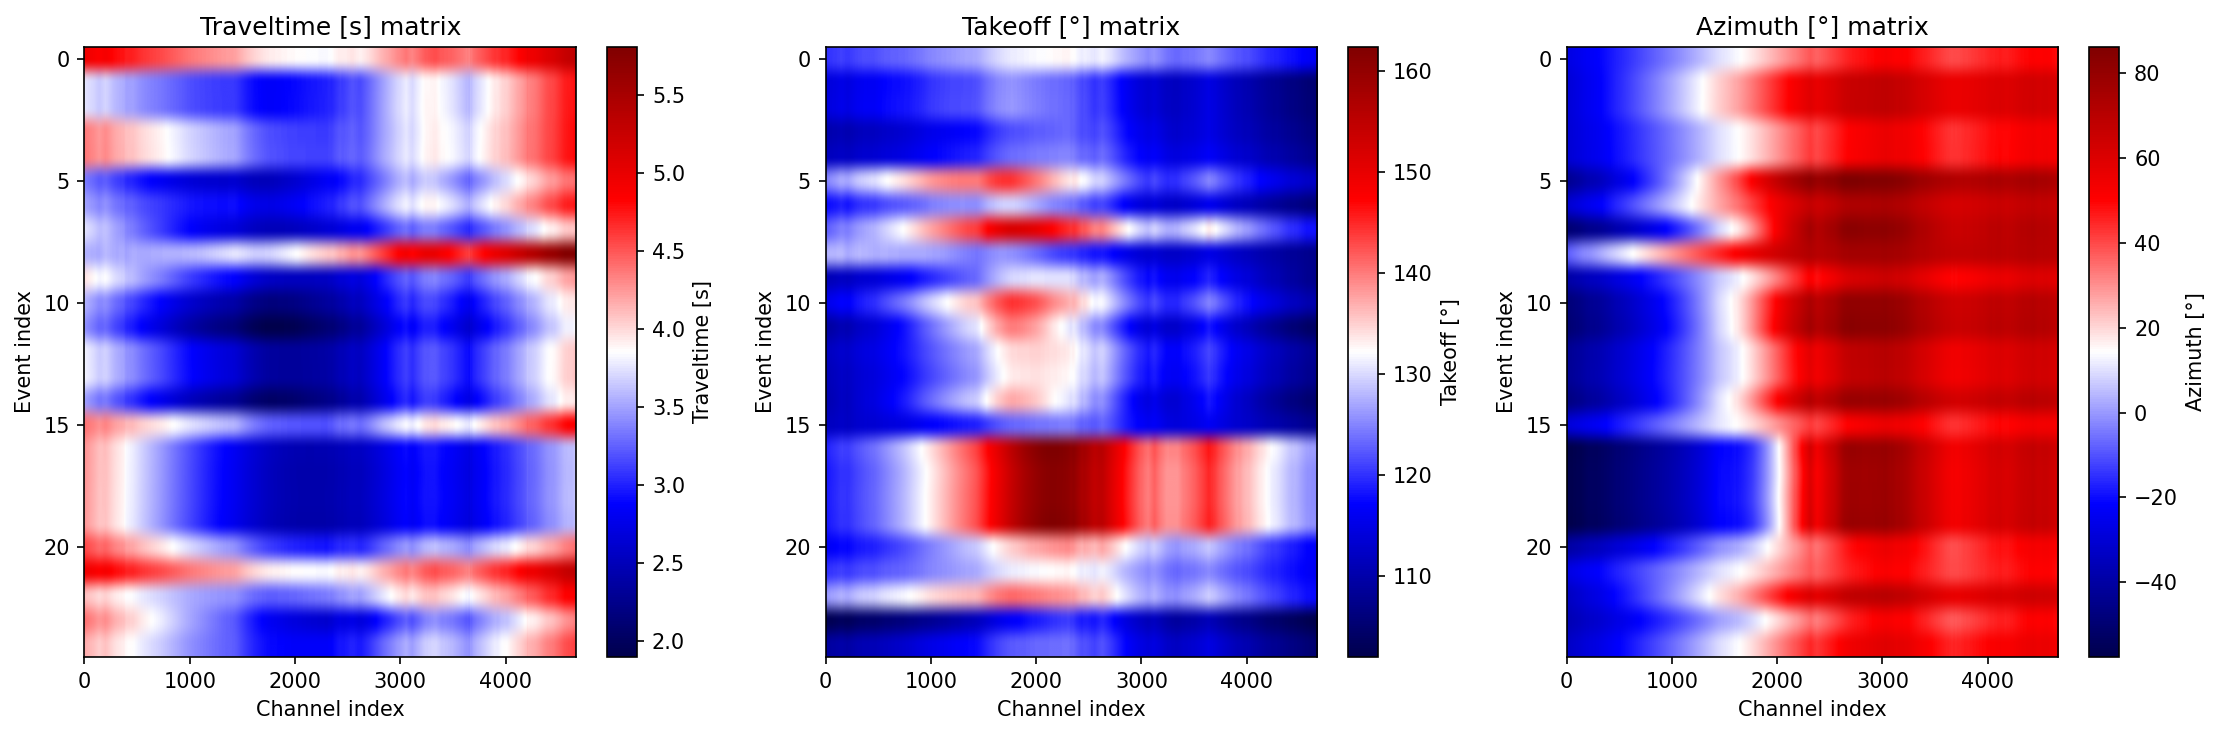

  → /home/tyan/joint_inversion/new_package/proj_25events/cache/figs/stage1_das_2d  (3 plots)
  Done  (210.7 s)


In [29]:
# Step 1b — DAS
if FORWARD_METHOD == "1d":
    step1_das_1d(PROJECT_DIR, EVENT_CATALOG, DAS_GEO, VEL_1D,
        grid_spacing_km=GRID_SPACE, compute_uncertainty=COMPUTE_UNCERTAINTY,
        monte_carlo_trials=MC_TRIALS, vertical_uncertainty_km=VERT_UNC,
        horizontal_uncertainty_km=HORIZ_UNC, show_plots=SHOW_PLOTS,
        num_cpu_workers=NUM_CPU)
elif FORWARD_METHOD == "2d":
    step1_das_2d(PROJECT_DIR, EVENT_CATALOG, DAS_GEO, VEL_1D, TOPO,
        grid_spacing_km=GRID_SPACE, das_subsample_interval=DAS_SUBSAMPLE,
        fiber_bend_threshold_deg=FIBER_BEND_THRESH, azimuth_interp_deg=AZIMUTH_INTERP_DEG,
        compute_uncertainty=COMPUTE_UNCERTAINTY, monte_carlo_trials=MC_TRIALS,
        vertical_uncertainty_km=VERT_UNC, horizontal_uncertainty_km=HORIZ_UNC,
        show_plots=SHOW_PLOTS,
        num_cpu_workers=NUM_CPU)
elif FORWARD_METHOD == "3d":
    step1_das_3d(PROJECT_DIR, EVENT_CATALOG, DAS_GEO, VEL_1D, TOPO,
        grid_spacing_km=GRID_SPACE, das_subsample_interval=DAS_SUBSAMPLE,
        fiber_bend_threshold_deg=FIBER_BEND_THRESH, compute_uncertainty=COMPUTE_UNCERTAINTY,
        monte_carlo_trials=MC_TRIALS, vertical_uncertainty_km=VERT_UNC,
        horizontal_uncertainty_km=HORIZ_UNC, show_plots=SHOW_PLOTS,
        num_cpu_workers=NUM_CPU)

## Step 2a — DAS Waveform Windowing (Lab 3b)

Extract short time windows around P- and S-wave arrivals from raw DAS HDF5 records. P/S arrival times come from PhaseNet-DAS phase picks.

- **Bandpass filter** (default 1–10 Hz) removes noise outside the frequency band of interest
- **Symmetric window** (default ±1 s) centered on each phase arrival
- Optionally applies **Hilbert transform** to separate P and S wave energy for hybrid polarity picking



  step2a_window — windowed DAS waveforms (no Hilbert)

[1/2] Process & save windowed waveforms
  Events      : 25  (from /home/tyan/joint_inversion/new_package/proj_25events/input/catalog_25events.csv)
  Channels    : 4670  (index 9–4986)


step2a_window:   0%|          | 0/25 [00:00<?, ?ev/s]

step2a_window: 100%|██████████| 25/25 [00:41<00:00,  1.66s/ev]


  Done: 25 ok
  → /home/tyan/joint_inversion/new_package/proj_25events/cache/das_win
[2/2] QC plots


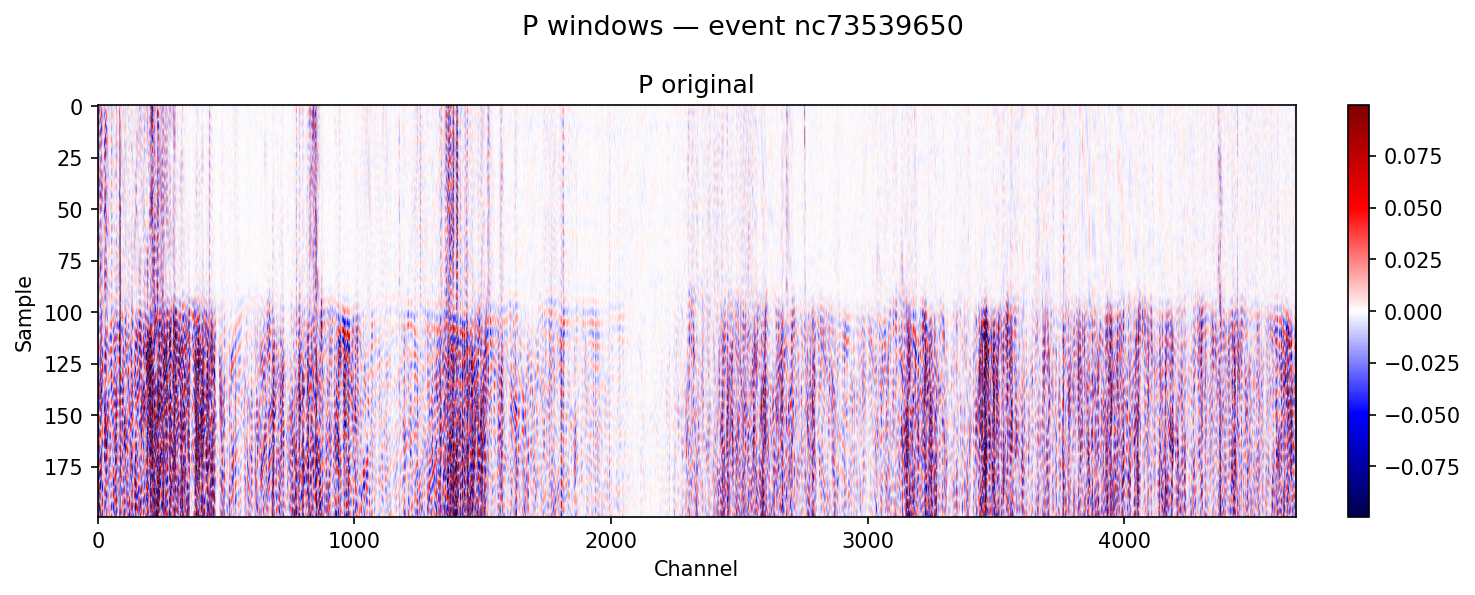

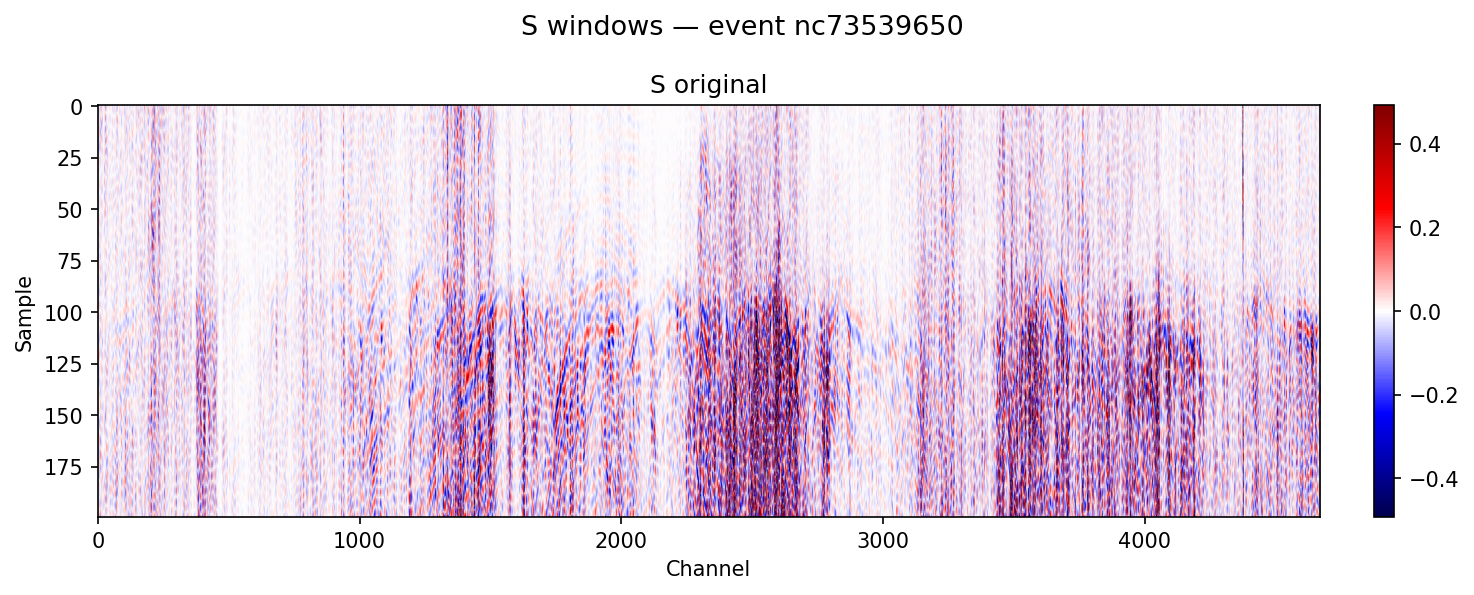

  → /home/tyan/joint_inversion/new_package/proj_25events/cache/figs/stage2a  (2 plots)


  Done  (42.2 s)



In [30]:
step2a_window(
    PROJECT_DIR, EVENT_CATALOG, DAS_RAW_DATA, DAS_RAW_TIME, DAS_GEO,
    das_win=DAS_WIN, das_fft=DAS_FFT,
    bandpass_freq_min_hz=FREQ_MIN, bandpass_freq_max_hz=FREQ_MAX,
    window_half_duration_sec=CUT_HALF_SEC, hilbert=HILBERT,
    device=DEVICE, num_cpu_workers=NUM_CPU, show_plots=SHOW_PLOTS,
)

## Step 2b — DAS MCCC Polarity Picking (Lab 3b)

Determine P-wave polarity along the DAS array using a data-driven approach:

1. **MCCC** — Multi-channel cross-correlation extracts relative polarity between all event pairs per channel
2. **SVD** — Singular value decomposition solves for consistent absolute polarity across all events (the first singular vector)
3. **Sign calibration** — Compare DAS polarity at the nearest channel with a known station polarity to resolve the global ±1 ambiguity

Reference: Li et al. (2023), *Nature Communications*, 14, 4181.



  step2b_polarity — MCCC + SVD (serial)

[1/4] Load precomputed FFT
  Events      : 25
  Channels    : 4670
  Total pairs : 300
  Hybrid LR   : False
  Dense Ckij/Skij: 0.02 GB (0.0% of 457.0 GB available)
  Estimated VRAM peak : 3.28 GB  /  42.90 GB available
  Single block (25 events fit in cache)
[2/4] MCCC cross-correlation (serial)


MCCC pairs:   0%|          | 0/300 [00:00<?, ?pair/s]

MCCC pairs: 100%|██████████| 300/300 [04:17<00:00,  1.17pair/s]


  MCCC done (300 pairs)
  MCCC cache saved: /home/tyan/joint_inversion/new_package/proj_25events/cache/mccc_pol/mccc_direct.h5  ((4670, 25, 25, 2), 23.4 MB)
[3/4] SVD polarity


  Pkic shape : (4670, 25)

[das_cal] Station → nearest DAS channel (38 stations, min_picks=5):
  Network  Station   DAS ch   Dist(km)   Polarities   Selected
  -------- -------- ------- ---------- ------------ ----------
  NP       1576        2309      0.040          304  <-- selected
  NC       MCB          695      0.826         1086  
  CI       MLAC        1268      0.904         1127  
  NC       MCO         1067      1.044         2220  
  NC       MGPB         675      1.269         1052  
  NC       MDR         1237      1.726         1927  
  NC       MCS          598      1.846         1319  
  NC       MMLB           9      2.308          687  
  NC       MMX1         149      2.553         1026  
  NC       MEM          233      2.589         1024  
  NC       MCV         1729      2.601         2293  
  NC       MLC          597      2.983         2422  
  NC       MDH          512      4.403          511  
  NC       MDH1         512      4.403          636  
  NC       

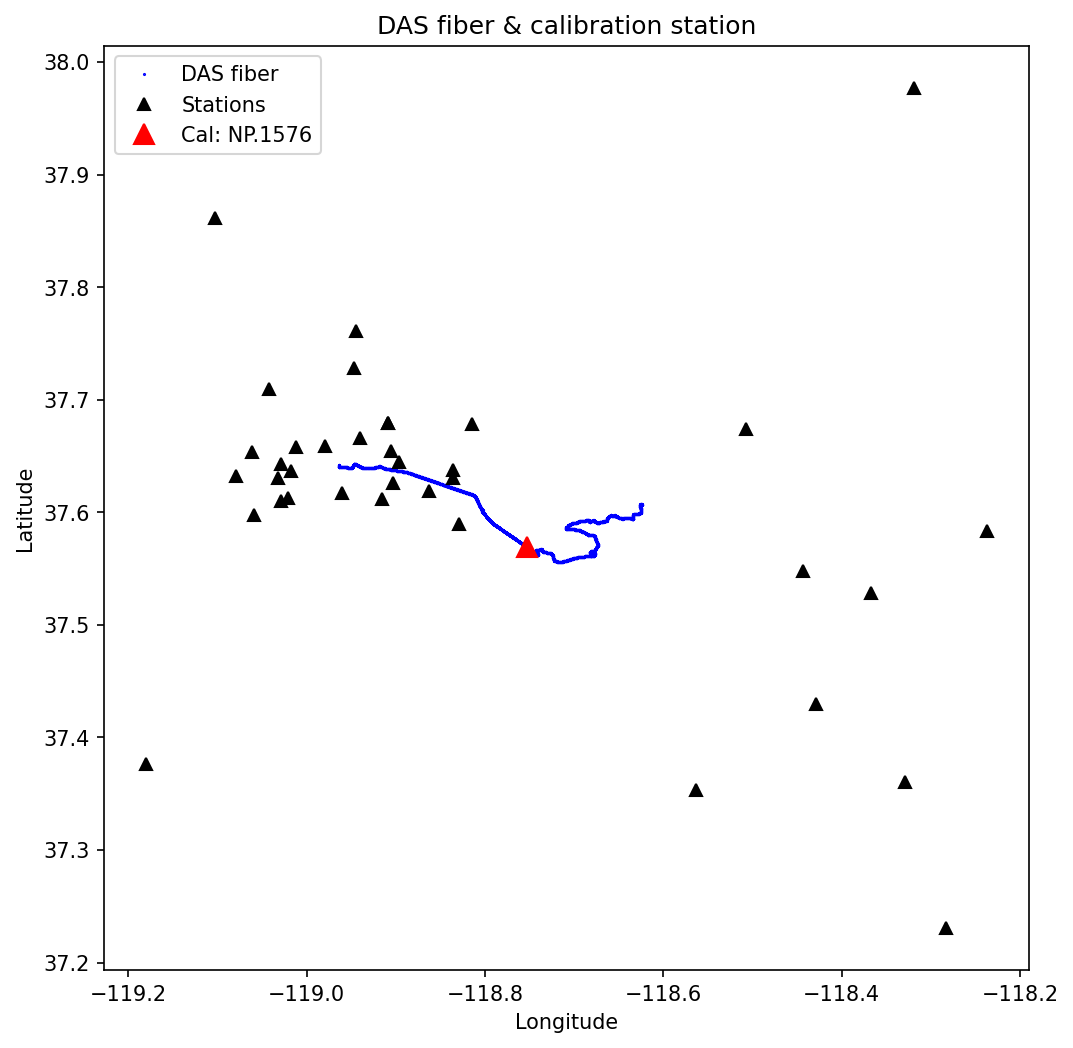

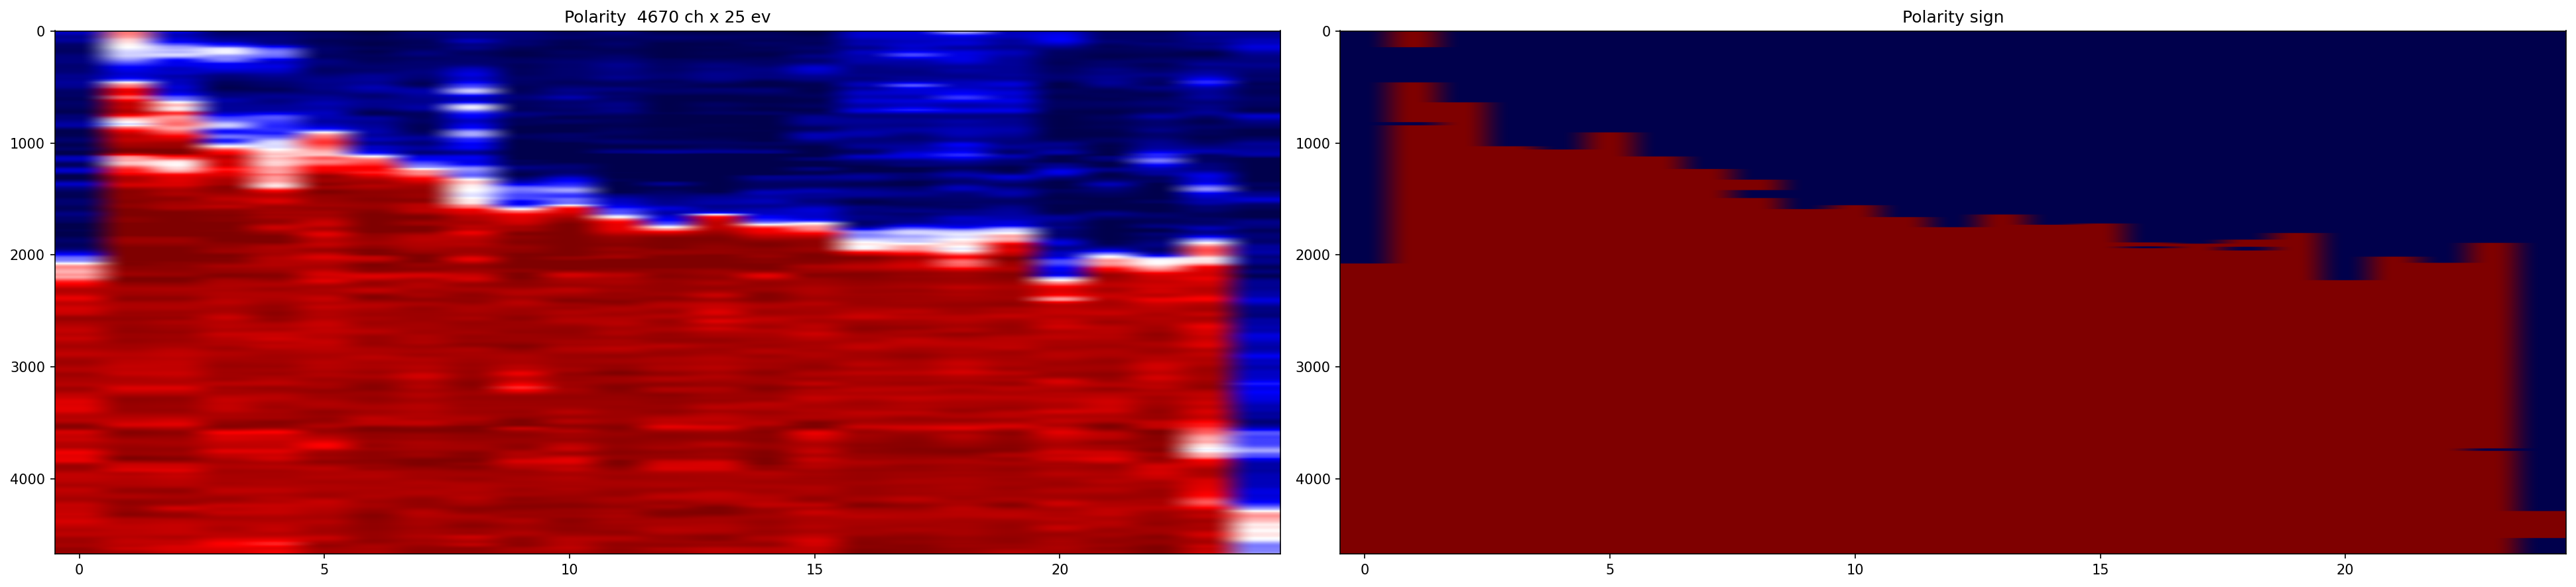

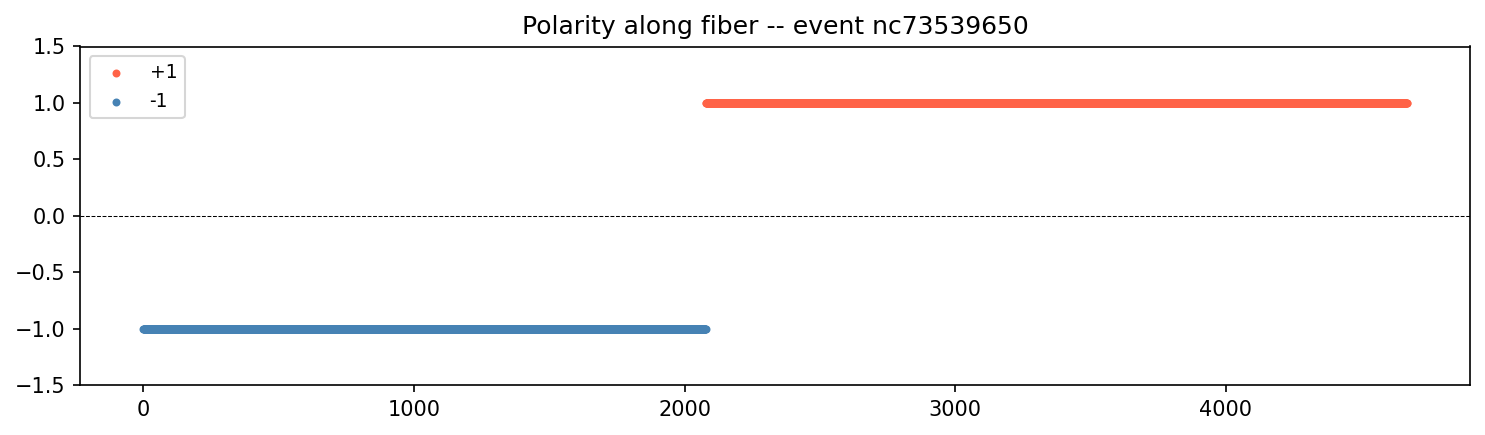

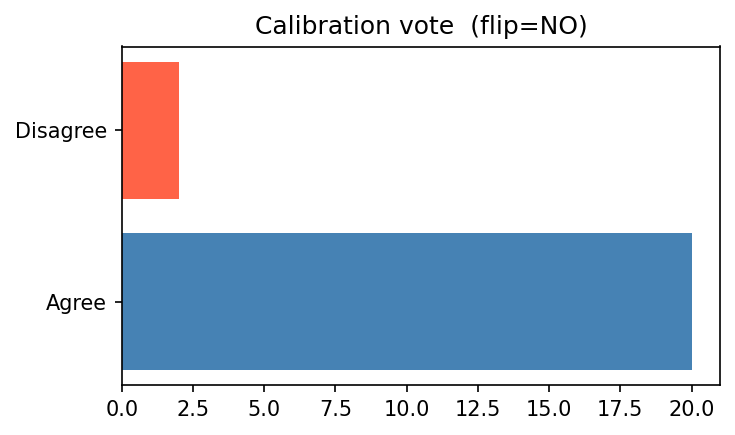

  -> /home/tyan/joint_inversion/new_package/proj_25events/cache/figs/stage2b  (4 plots)

  Done  (260.3 s)


In [31]:
step2b_polarity(
    PROJECT_DIR,
    event_catalog=EVENT_CATALOG, das_fft=DAS_FFT, das_geo=DAS_GEO,
    mccc_cache_path=MCCC_CACHE_PATH, pol_out_path=DAS_POL,
    polarity_method=POLARITY_METHOD, polarity_smooth_window=POLARITY_SMOOTH_WIN,
    mccc_max_lag_sec=MCCC_MAX_LAG_SEC, mccc_maxwin=MCCC_MAXWIN,
    mccc_damp=MCCC_DAMP, mccc_max_shift=MCCC_MAX_SHIFT,
    sta4mccc_ref=STA4MCCC_REF, sta_polarity=STA_POL, sta_geo=STA_GEO,
    cal_min_picks=CAL_MIN_PICKS, sparse=SPARSE_SOLVE,
    device=DEVICE, num_cpu_workers=NUM_CPU, show_plots=SHOW_PLOTS,
)

## Step 2c — DAS S/P Amplitude Ratio Extraction (Lab 3b)

Compute log10(S/P) amplitude ratios from the windowed DAS waveforms:

- Pick P and S amplitudes from each channel's time window
- Channels with zero P or S amplitude are marked invalid



  step2c_spratio — Extract DAS S/P amplitude ratios

[1/4] Load & pick S/P ratios per event


S/P ratio: 100%|██████████| 25/25 [00:01<00:00, 21.75ev/s]


  Done: 25 ok
  Channels    : 4670
  dt          : 0.01 s
[2/4] Assemble S/P ratios
  Valid frac  : 100.0%
[4/4] Save & QC plots
  → /home/tyan/joint_inversion/new_package/proj_25events/cache/sp_ratios/sp_ratios.h5


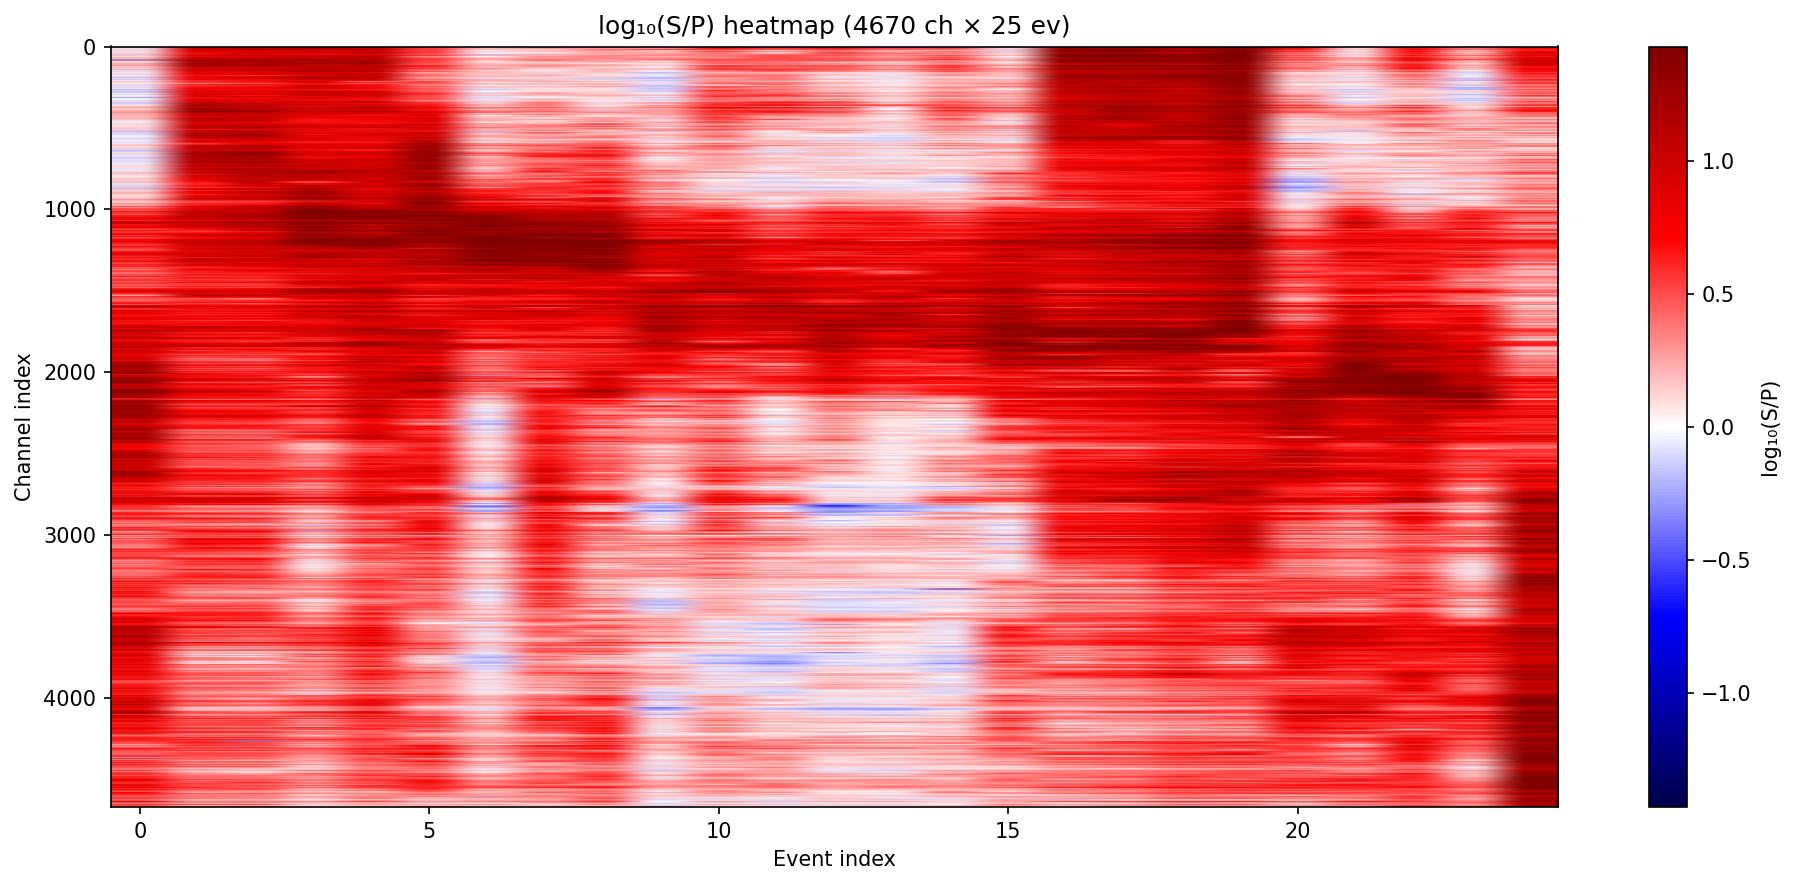

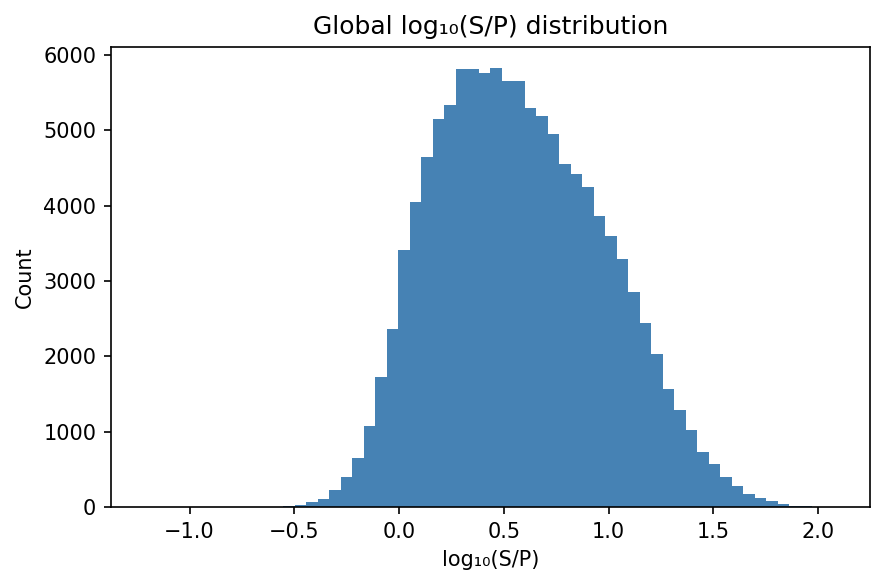

  → /home/tyan/joint_inversion/new_package/proj_25events/cache/figs/stage2c  (2 plots)


  Done  (1.7 s)



In [32]:
step2c_spratio(
    PROJECT_DIR,
    event_catalog=EVENT_CATALOG, das_win=DAS_WIN, das_geo=DAS_GEO,
    sp_out_path=DAS_SP,
    num_cpu_workers=NUM_CPU,
    show_plots=SHOW_PLOTS,
)

## Step 3 — Focal Mechanism Inversion (Lab 3c)

Grid search over strike/dip/rake space to find focal mechanisms consistent with observed polarity and S/P amplitude ratios. Supports 7 inversion modes combining station and DAS data:

| # | Data uesed | Internal name | Solver |
|---|-----------|---------------|--------|
| 1 | `sta_pol` | STA_pol | pol-only |
| 2 | `sta_pol + sta_sp` | STA_pol_sp | joint |
| 3 | `das_pol` | DAS_pol | pol-only |
| 4 | `das_pol + das_sp` | DAS_pol_sp | joint |
| 5 | `sta_pol + das_pol` | STA_pol_DAS_pol | pol-only |
| 6 | `sta_pol + das_sp` | STA_pol_DAS_sp | joint |
| 7 | `sta_pol + das_pol + das_sp` | STA_pol_DAS_pol_sp | joint |

The search uses a two-stage approach: first relax polarity threshold (min_misfit + buffer) to build a pool, then filter by S/P amplitude within the pool, until ≥20 acceptable solutions are found, then applies hierarchical clustering to identify distinct focal mechanism candidates.

In [37]:
step3_invert(
    PROJECT_DIR,
    event_catalog=EVENT_CATALOG, forward_method=FORWARD_METHOD,
    inversion_types=INVERSION_TYPES, compute_uncertainty=COMPUTE_UNCERTAINTY,
    result_dir=RESULT_DIR,
    das_geo=DAS_GEO, das_polarity=DAS_POL, das_sp_ratio=DAS_SP,
    sta_geo=STA_GEO, sta_polarity=STA_POL, sta_sp_ratio=STA_SP,
    vs_vp_ratio=VS_VP_RATIO,
    sp_decay_k=SP_DECAY_K, sp_decay_c=SP_DECAY_C,
    weighted_polarity=WEIGHTED_POLARITY, das_pol_weight=DAS_POL_WEIGHT,
    sdr_grid_dang_deg=SDR_GRID_DANG, init_pol_error=INIT_POL_ERROR,
    init_amp_error_perc=INIT_AMP_ERROR_PERC,
    joint_pol_size=JOINT_POL_SIZE, sp_norm=SP_NORM,
    device=DEVICE, num_cpu_workers=NUM_CPU,
)


  step3_invert — Focal mechanism inversion (single pass, single cuda:1)

[1/5] Configuration
  Forward     : 2d
  Result dir  : /home/tyan/joint_inversion/new_package/proj_25events/result_try1
  Inv types   : ['STA_pol', 'STA_pol_sp', 'DAS_pol', 'DAS_pol_sp', 'STA_pol_DAS_pol', 'STA_pol_DAS_sp', 'STA_pol_DAS_pol_sp']
  need_das_pol=True  need_das_sp=True  need_sta_pol=True  need_sta_sp=True
[2/5] Load data
  DAS polarity loaded: (4670, 25)  pol_valid: 4670-4670 ch/ev
  DAS SP ratios loaded: (4670, 25)
  DAS alignment OK: 25 events x 4670 channels
  DAS ray params loaded (nominal): (25, 4670)
  Station ray params loaded: table_sta_2d.h5
  Station polarity: 25 events (src: table_sta_*.h5)
  Station S/P: 24 events (src: table_sta_*.h5)
[4/5] Build SDR grid
  Grid size: 30996 focal mechanisms
  [serial] device=cuda:1  events=25


events: 100%|██████████| 25/25 [00:55<00:00,  2.23s/ev]

  Done  (55.9 s)
  -> /home/tyan/joint_inversion/new_package/proj_25events/result_try1


## Step 3b — Beachball Plots (Lab 3c)

Generate beachball plots for all events and inversion modes. Each plot shows:

- Grey outlines — all acceptable focal mechanism solutions
- Red-edged beachball — best-fit solution
- Red/blue dots — DAS polarity observations (positive/negative)
- Triangles — station polarity observations
- Title — quality grade, solution probability, and all inversion metricses

  step3_plot — Generate beachball plots
  Result dir: /home/tyan/joint_inversion/new_package/proj_25events/result_try1
  Events: 25


plotting: 100%|██████████| 25/25 [00:32<00:00,  1.30s/ev]


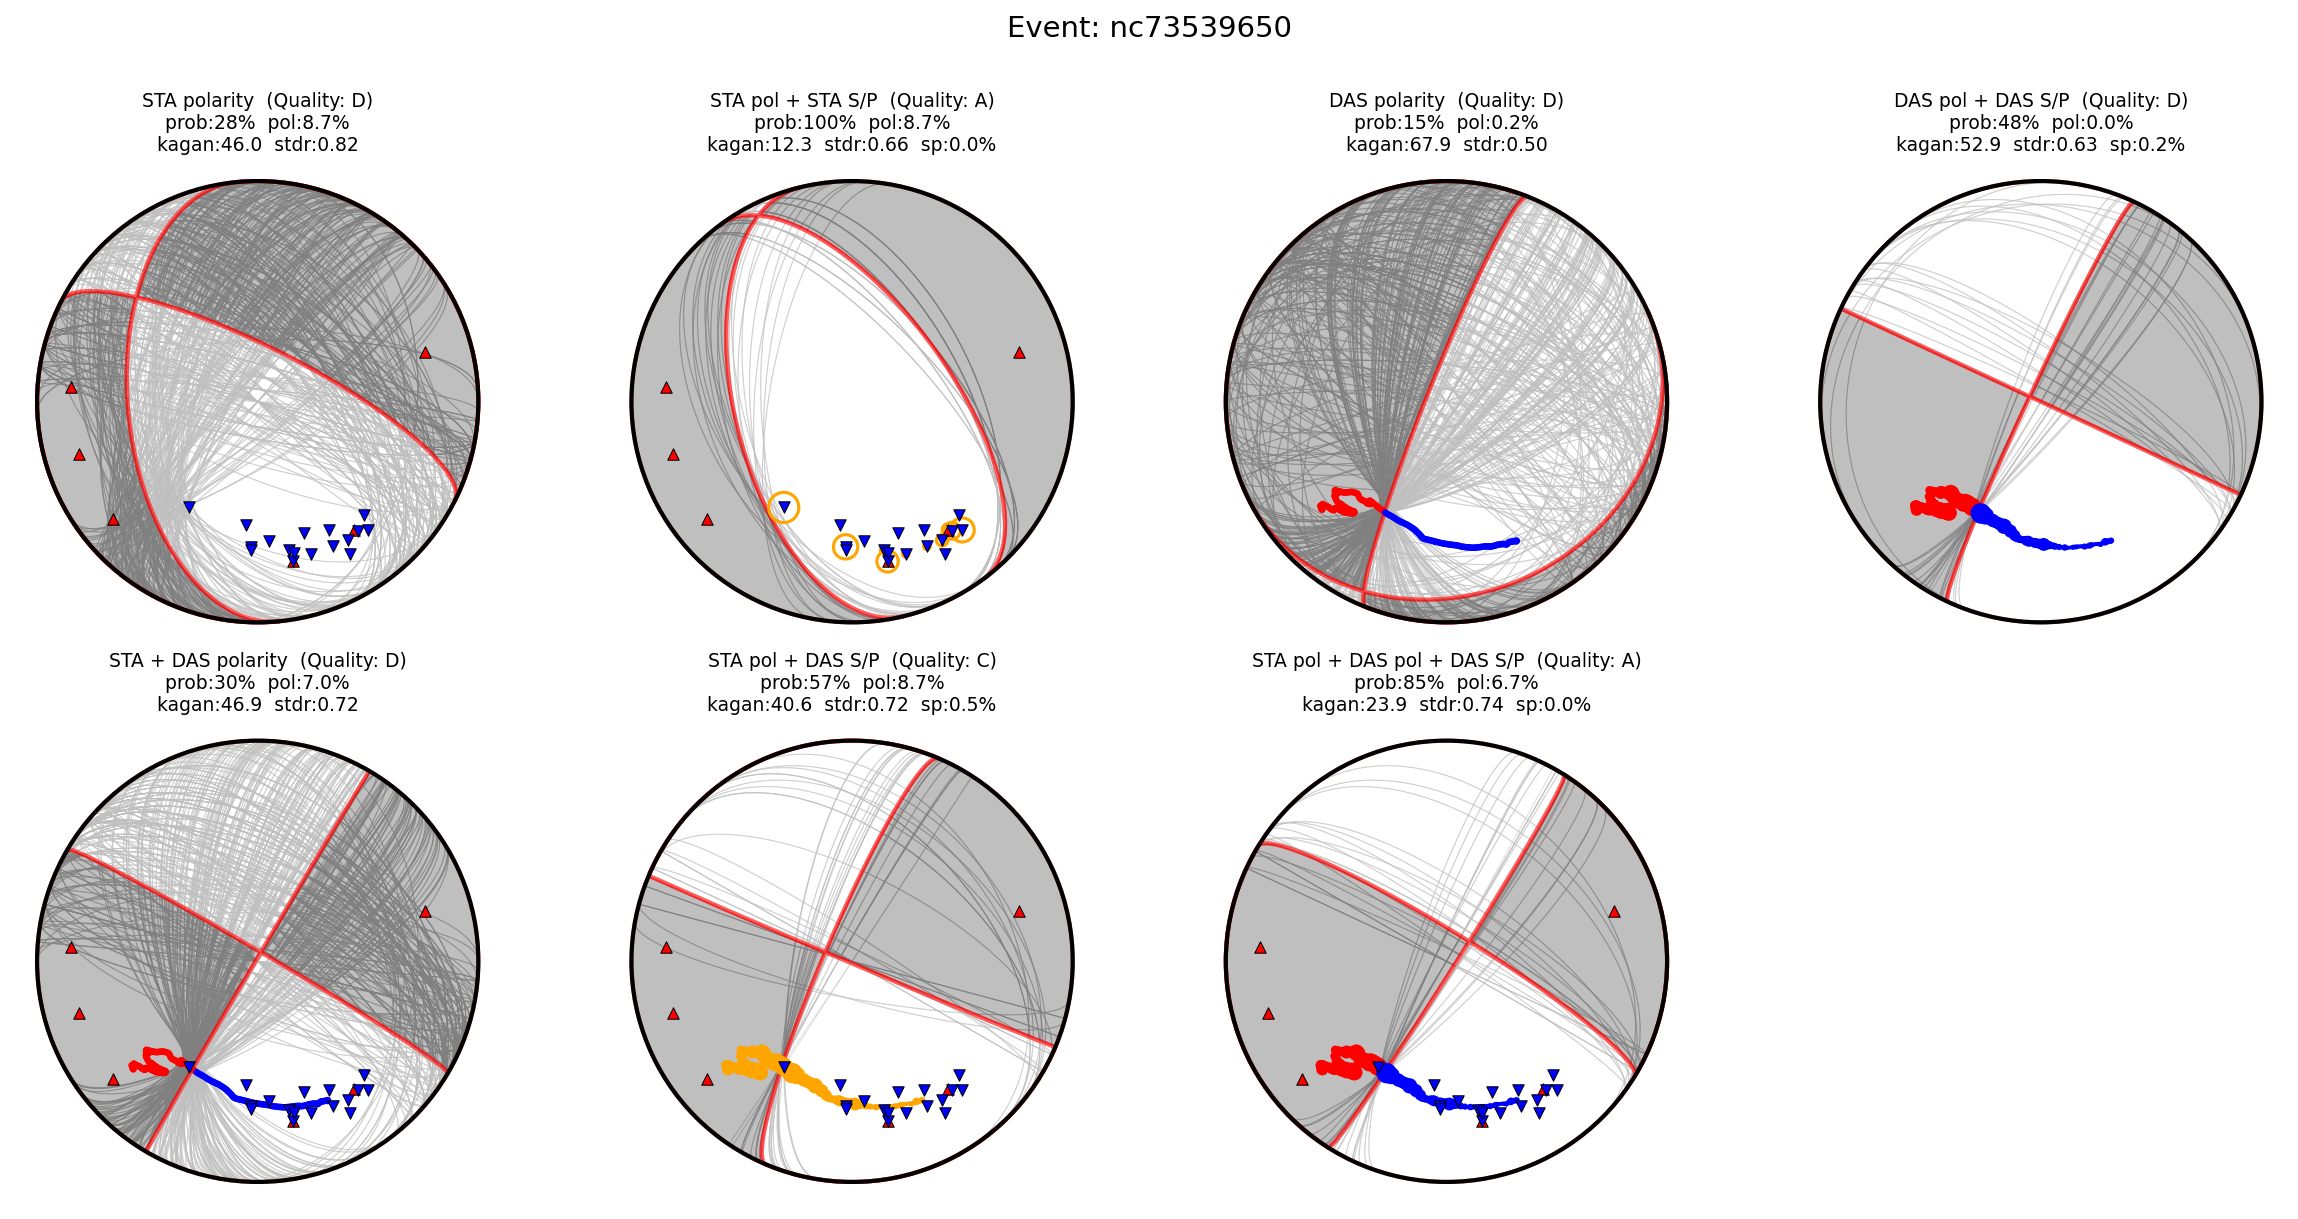

  Generated 174 subplot plots across 25 events


In [38]:
step3_plot(
    PROJECT_DIR,
    event_catalog=EVENT_CATALOG, inversion_types=INVERSION_TYPES,
    result_dir=RESULT_DIR,
    fig_dir=FIG_DIR, num_cpu_workers=NUM_CPU,
    show_plots=SHOW_PLOTS,
)

## Step 4 — Summarize Results (Lab 3d)

Evaluate solution quality and export results:

- **Quality grading** — each solution is assigned A/B/C/D based on 5 metrics: polarity misfit, Kagan angle uncertainty, STDR, solution probability, and S/P misfit rate (joint modes only)
- **Grade distribution** — bar chart comparing quality across all inversion modes
- **SKHASH export** — CSV files compatible with the SKHASH focal mechanism format


  step4_summarize — Summarize inversion results

  Result dir  : /home/tyan/joint_inversion/new_package/proj_25events/result_try1
[1/4] Load results
  Events      : 25
  STA_pol             : 25/25 events with solutions, 66 total candidates
  STA_pol_sp          : 24/25 events with solutions, 34 total candidates
  DAS_pol             : 25/25 events with solutions, 121 total candidates
  DAS_pol_sp          : 25/25 events with solutions, 40 total candidates
  STA_pol_DAS_pol     : 25/25 events with solutions, 45 total candidates
  STA_pol_DAS_sp      : 25/25 events with solutions, 31 total candidates
  STA_pol_DAS_pol_sp  : 25/25 events with solutions, 33 total candidates
  Stat mode           : best candidate
[2/4] Quality grading


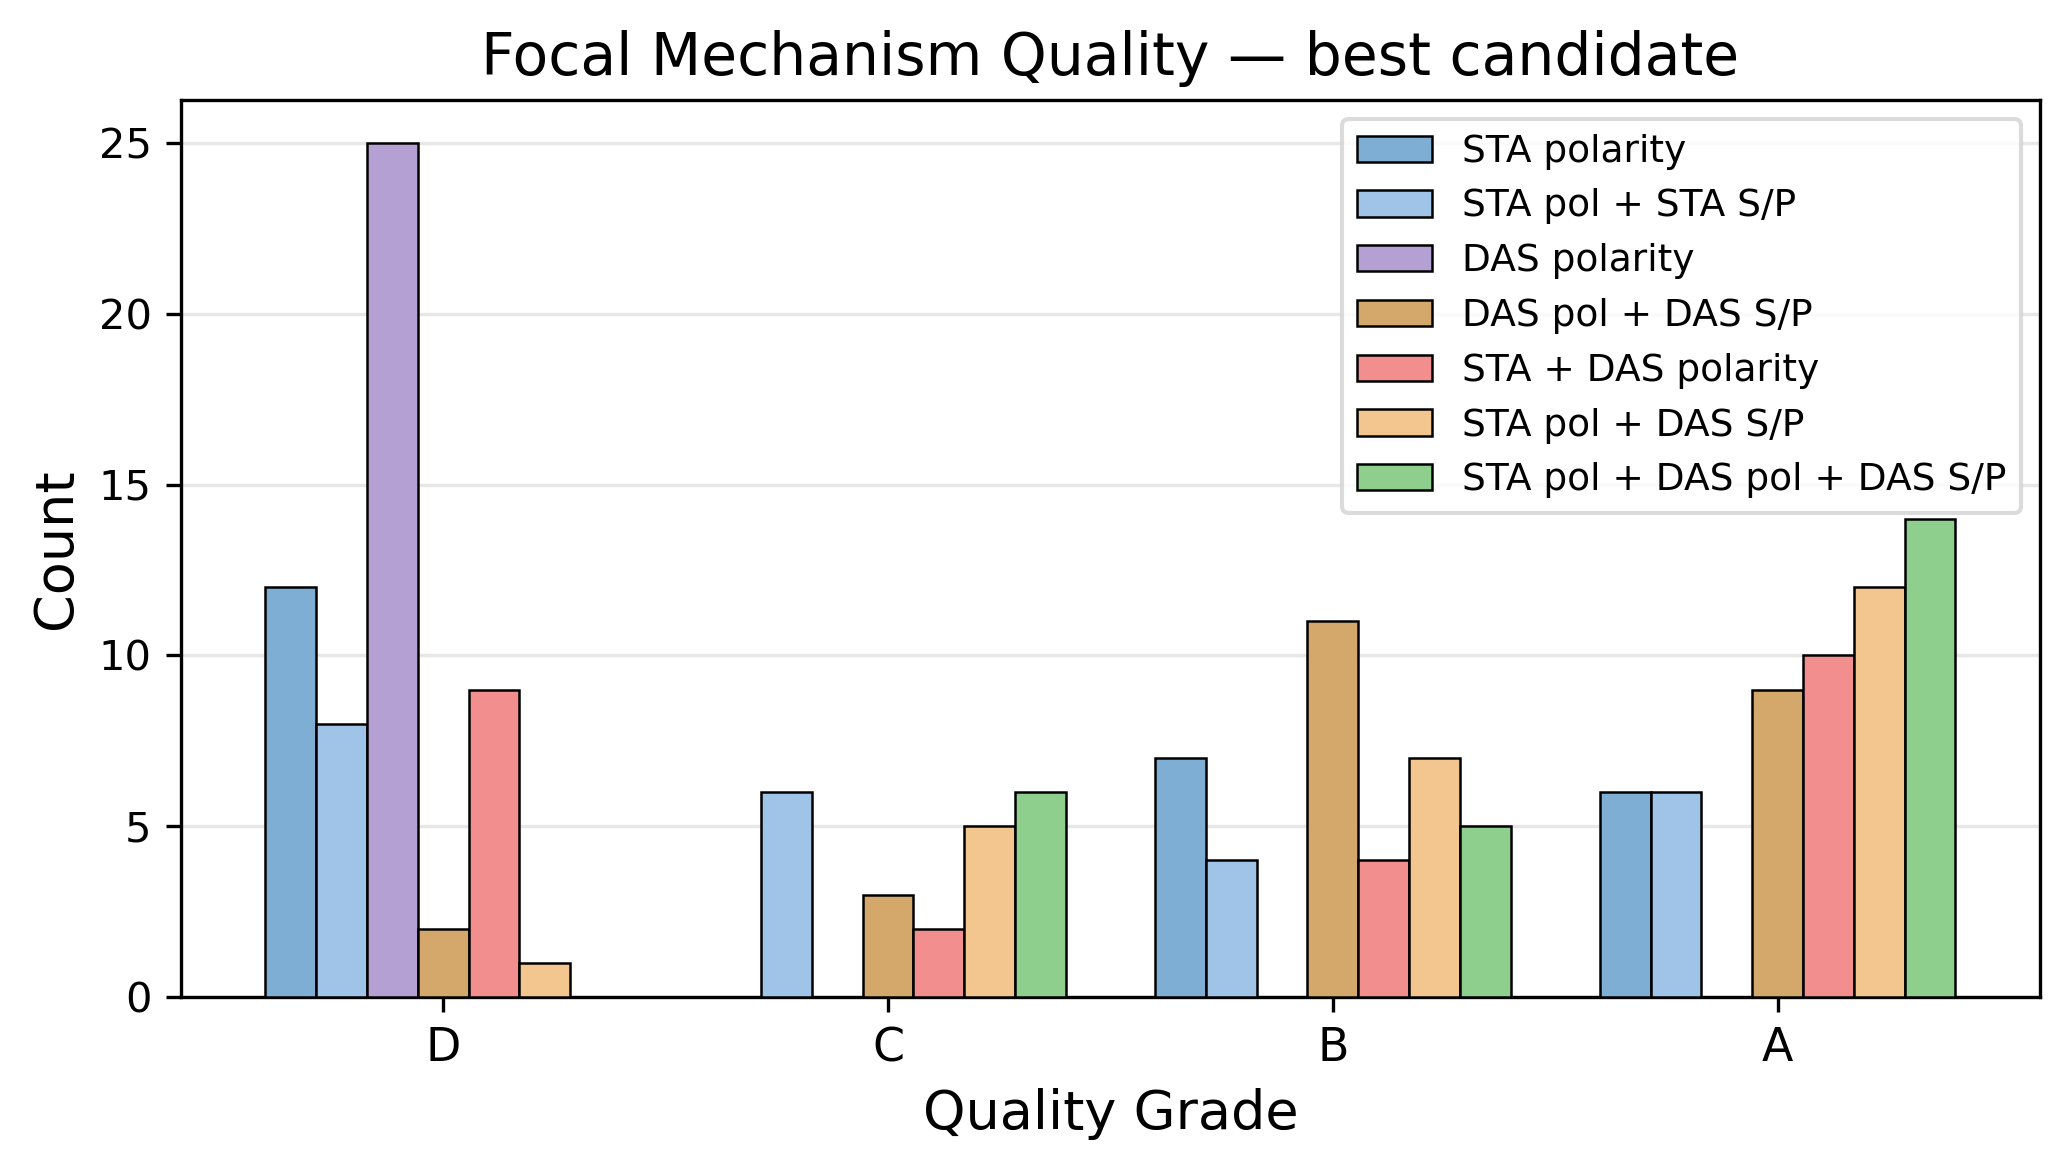

  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/summary_figs/quality_comparison_4modes.png

Quality Grade Summary
Grade                 STA polarity   STA pol + STA S/P        DAS polarity   DAS pol + DAS S/P  STA + DAS polarity   STA pol + DAS S/PSTA pol + DAS pol + DAS S/P
------------------------------------------------------------
A                                6                   6                   0                   9                  10                  12                  14
B                                7                   4                   0                  11                   4                   7                   5
C                                0                   6                   0                   3                   2                   5                   6
D                               12                   8                  25                   2                   9                   1                   0
----------------------

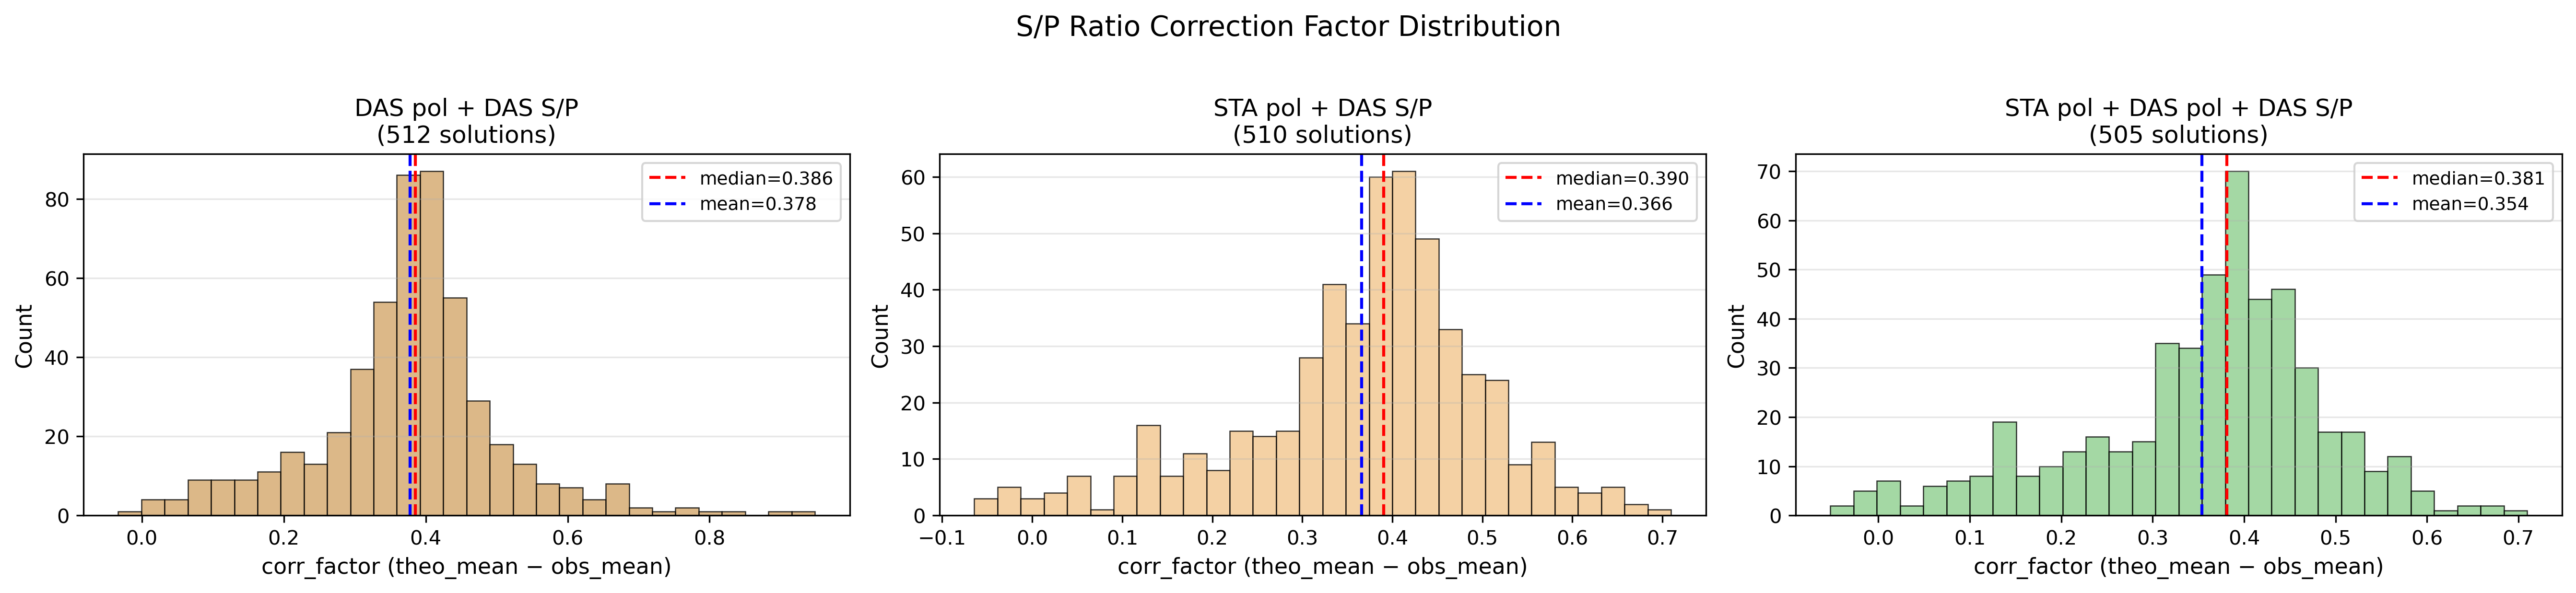

  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/summary_figs/corr_factor_distribution.png
[4/4] Export SKHASH
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/STA_poloutfile1.csv  (25 events)
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/STA_poloutfile2.csv  (11846 mechanisms)
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/STA_pol_spoutfile1.csv  (24 events)
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/STA_pol_spoutfile2.csv  (454 mechanisms)
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/DAS_poloutfile1.csv  (25 events)
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/DAS_poloutfile2.csv  (12008 mechanisms)
  → /home/tyan/joint_inversion/new_package/proj_25events/result_try1/skhash_format/DAS_pol_spoutfile1.csv  (25 events)
  → /home/tyan/joint_inversio

In [39]:
SUM_MODE = INVERSION_TYPES  
# You can modify this to only summarize specific modes, e.g. ["sta_pol", "sta_pol + das_pol + das_sp"]

step4_summarize(
    PROJECT_DIR, EVENT_CATALOG, SUM_MODE,
    compute_uncertainty=COMPUTE_UNCERTAINTY,
    result_dir=RESULT_DIR,
    best_only=BEST_ONLY,
    show_plots=SHOW_PLOTS,
)